This notebook outlines a pipeline for **multi-class classification** of mycetoma species. It uses **domain-independent features** extracted by a pre-trained deep learning model via **Img2Vec**. The histopathology images are first pre-processed with **Macenko stain normalization** before being fed into the model.

The core of this approach is to use a deep learning model to create a feature vector for each image, which serves as a richer, more abstract representation than traditional hand-crafted features. This feature vector is then used to train classical machine learning models for the final classification task.

The notebook uses the following machine learning classifiers:
* **Random Forest**
* **Decision Tree**

The notebook also uses **Randomized Search** and **Grid Search** to optimize the model's performance by finding the best **hyperparameters**, such as the number of estimators and maximum tree depth, for the Random Forest classifier. The model's performance is evaluated by generating a classification report and a confusion matrix.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# standard library
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.simplefilter('ignore')

import matplotlib.pyplot as plt
%matplotlib inline
import os
import pprint
from collections import Counter
import joblib
from pprint import pprint
import cv2

# skimage libraries
from skimage.io import imread
from skimage.transform import resize
#from skimage.feature import hog
from skimage.transform import rescale

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [ ]:
!pip install --quiet img2vec_pytorch
from img2vec_pytorch import Img2Vec
from PIL import Image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 31.2 MB/s eta 0:00:00


In [ ]:
#function to load dataset and extract features
#To explore the relations between meme and non-meme images, we vectorize the images using Img2Vec.
#Img2Vec is a pre-trained pytorch model that proves to perform well for image classification
def load_dataset_and_extract_features(data_dir):
  img2vec = Img2Vec()
  features =[]
  labels = []
  for category in os.listdir(data_dir):
    for img_path in os.listdir(os.path.join(data_dir,category)):
      img_path_ = os.path.join(data_dir,category, img_path)
      img = cv2.imread(img_path_)
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)#CONVERT bgr TO rgb
      img = cv2.resize(img, (224,224)) #resize image to a standard size
      img = Image.fromarray(img) #convert Numpy array to PIL Image
      img_features = img2vec.get_vec(img)
      features.append(img_features)
      labels.append(category)
  return features, labels

In [ ]:
train_dir = "/content/drive/MyDrive/MACENKO SET/train/"
val_dir= "/content/drive/MyDrive/MACENKO SET/test/"

In [ ]:
train_features, train_labels = load_dataset_and_extract_features(train_dir)
val_features, val_labels = load_dataset_and_extract_features(val_dir)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 107MB/s]


In [ ]:
# Define class mapping
class_mapping = {
    "actionmadureapelletrii": "AP",
    "falciformisporasenegalensis": "FS",
    "madurellamycetomatis": "MM",
    "streptomycessomaliesnis": "SS"
}

In [ ]:
# Convert labels to short names
train_labels = [class_mapping[label] for label in train_labels]
val_labels = [class_mapping[label] for label in val_labels]

In [ ]:
#Decision tree model and evaluation
dt_model= DecisionTreeClassifier(random_state=42)
dt_model.fit(train_features,train_labels)
y_pred_dt=dt_model.predict(val_features)

In [ ]:
print("Decison Tree Model performance:")
print("Accuracy:", accuracy_score(val_labels,y_pred_dt),'\n')
print("Classification Report:")
print(classification_report(val_labels,y_pred_dt))

Decison Tree Model performance:
Accuracy: 0.7819548872180451 

Classification Report:
              precision    recall  f1-score   support

          AP       0.69      0.79      0.74        72
          FS       0.71      0.65      0.68        37
          MM       0.94      0.89      0.91       114
          SS       0.63      0.60      0.62        43

    accuracy                           0.78       266
   macro avg       0.74      0.73      0.74       266
weighted avg       0.79      0.78      0.78       266



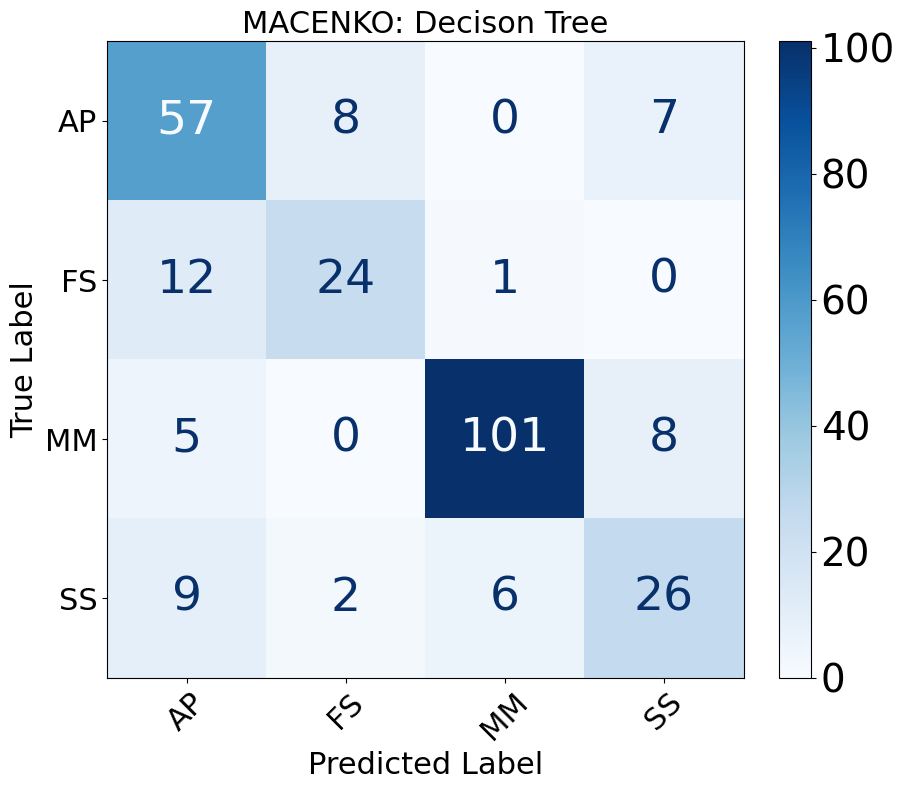

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt = confusion_matrix(val_labels, y_pred_dt, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("MACENKO: Decison Tree", fontsize=22)
plt.xlabel("Predicted Label", fontsize=22)
plt.ylabel("True Label", fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
##############################################################
##############################################################

In [ ]:
#Random Forest model and evaluation
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(train_features, train_labels)
#Test performance
y_pred_rf = rf_model.predict(val_features)

In [ ]:
print("\nRandom Forest Model Performance:")
print("Accuracy:", accuracy_score(val_labels, y_pred_rf),'\n')
print("Classification Report:")
print(classification_report(val_labels,y_pred_rf))


Random Forest Model Performance:
Accuracy: 0.8872180451127819 

Classification Report:
              precision    recall  f1-score   support

          AP       0.74      1.00      0.85        72
          FS       1.00      0.59      0.75        37
          MM       0.96      0.99      0.97       114
          SS       1.00      0.67      0.81        43

    accuracy                           0.89       266
   macro avg       0.92      0.82      0.84       266
weighted avg       0.91      0.89      0.88       266



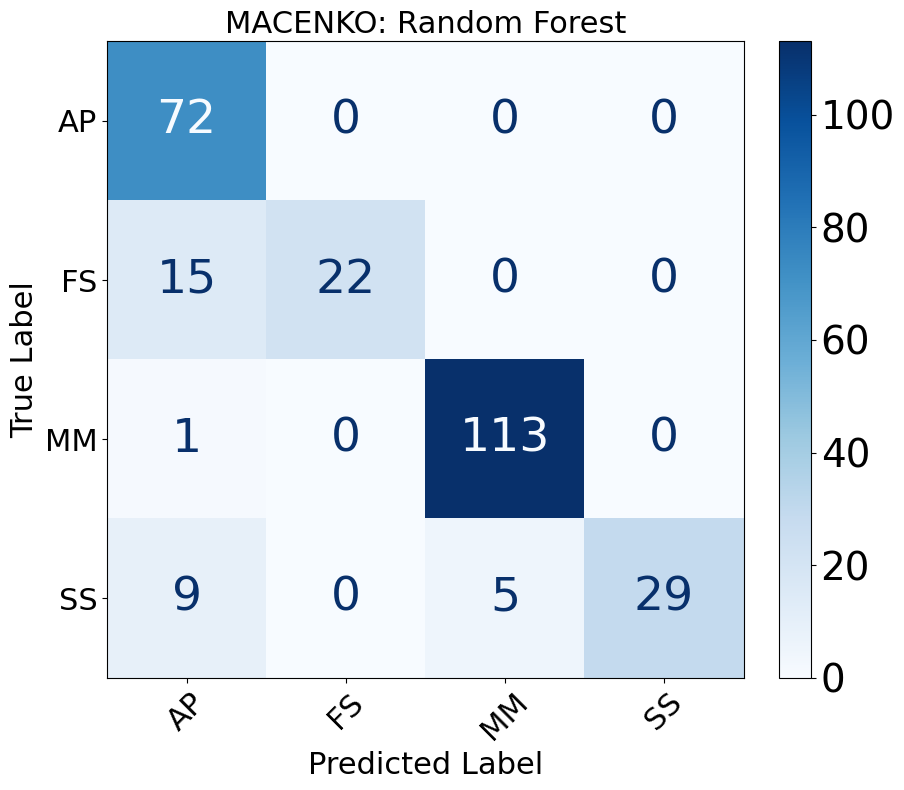

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(val_labels, y_pred_rf, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("MACENKO: Random Forest", fontsize=22)
plt.xlabel("Predicted Label", fontsize=22)
plt.ylabel("True Label", fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
##############################################################
##############################################################

In [ ]:
#II- Pre - Pruning for Cost Complexity
#Initialized Hyperparameters
#Grid Search Performance

In [ ]:
##Define hyperparameters for Decision tree
dt_params = {'criterion':['gini','entropy'],
            'splitter':['best','random'],
             'max_depth': [None,10, 20, 30],
             'min_samples_leaf':[1,2,4]
            }

In [ ]:
# Perform Grid Search for Decision Tree
dt_grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                              param_grid=dt_params, cv=5)
dt_grid_search.fit(train_features, train_labels)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'splitter': ['best', 'random']})

In [ ]:
tuning_result_dt_gs = pd.DataFrame(dt_grid_search.cv_results_)

In [ ]:
dt_grid_search.best_params_ #clf = dt_grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 4,
 'splitter': 'best'}

In [ ]:
# Decision Tree and Grid Search
y_pred_dt_gs = dt_grid_search.predict(val_features)
print("\nDecision Tree Grid Search Performance:")
print("Accuracy:", accuracy_score(val_labels, y_pred_dt_gs))
print("Classification Report:")
print(classification_report(val_labels, y_pred_dt_gs))


Decision Tree Grid Search Performance:
Accuracy: 0.8120300751879699
Classification Report:
              precision    recall  f1-score   support

          AP       0.69      0.82      0.75        72
          FS       0.69      0.59      0.64        37
          MM       0.95      0.96      0.96       114
          SS       0.78      0.58      0.67        43

    accuracy                           0.81       266
   macro avg       0.78      0.74      0.75       266
weighted avg       0.81      0.81      0.81       266



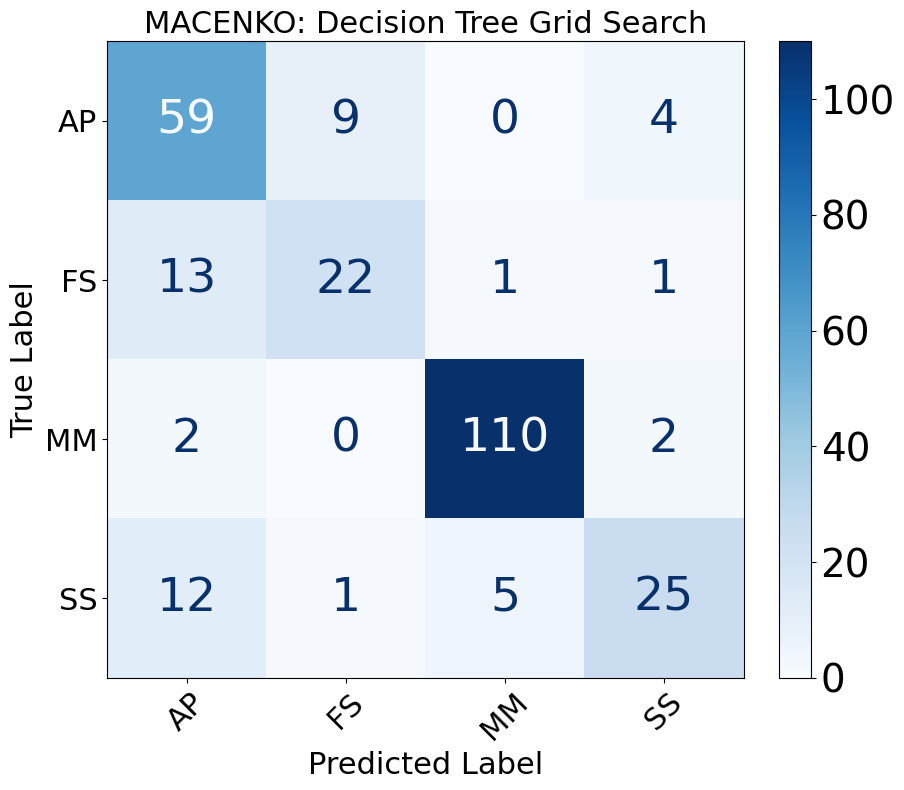

In [ ]:

# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt_gs = confusion_matrix(val_labels, y_pred_dt_gs, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_gs,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("MACENKO: Decision Tree Grid Search", fontsize=22)
plt.xlabel("Predicted Label", fontsize=22)
plt.ylabel("True Label", fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
##############################################################
##############################################################

In [ ]:
#Define hyperparameters for Random Forest
rf_params = {
    'n_estimators': [100, 200, 300], #https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [ ]:
# Perform Grid Search for Random Forest
rf_grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                              param_grid=rf_params, cv=5)
rf_grid_search.fit(train_features, train_labels)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]})

In [ ]:
# Random Forest Grid Search
y_pred_rf_gs = rf_grid_search.predict(val_features)
print("\nRandom Forest Grid Search Performance:")
print("Accuracy:", accuracy_score(val_labels, y_pred_rf_gs))
print("Classification Report:")
print(classification_report(val_labels, y_pred_rf_gs))


Random Forest Grid Search Performance:
Accuracy: 0.8796992481203008
Classification Report:
              precision    recall  f1-score   support

          AP       0.73      1.00      0.84        72
          FS       1.00      0.57      0.72        37
          MM       0.96      0.99      0.97       114
          SS       1.00      0.65      0.79        43

    accuracy                           0.88       266
   macro avg       0.92      0.80      0.83       266
weighted avg       0.91      0.88      0.87       266



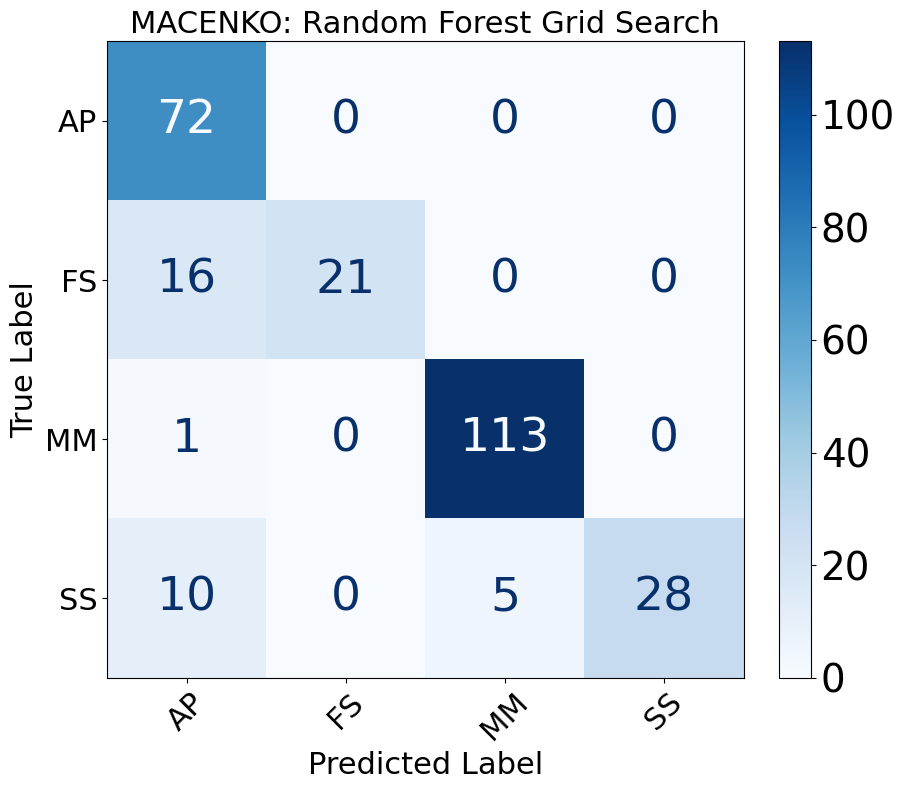

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf_gs = confusion_matrix(val_labels, y_pred_rf_gs, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_gs,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("MACENKO: Random Forest Grid Search", fontsize=22)
plt.xlabel("Predicted Label", fontsize=22)
plt.ylabel("True Label", fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



In [ ]:
##############################################################
##############################################################

In [ ]:
#Hyperparameter optimization using Randomized Search

In [ ]:
# Perform Randomized Search for Decision Tree
dt_random_search = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                                      param_distributions=dt_params, n_iter=100, cv=5, random_state=42)
dt_random_search.fit(train_features, train_labels)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=100,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'splitter': ['best', 'random']},
                   random_state=42)

In [ ]:
tuning_result_dt_rs = pd.DataFrame(dt_random_search.cv_results_)

In [ ]:
dt_random_search.best_params_

{'splitter': 'best',
 'min_samples_leaf': 4,
 'max_depth': None,
 'criterion': 'gini'}

In [ ]:
# Decision Tree Randomized Search
y_pred_dt_rs = dt_random_search.predict(val_features)
print("\n Decision Tree Randomized Search Performance:")
print("Accuracy:", accuracy_score(val_labels, y_pred_dt_rs))
print("Classification Report:")
print(classification_report(val_labels, y_pred_dt_rs))


 Decision Tree Randomized Search Performance:
Accuracy: 0.8120300751879699
Classification Report:
              precision    recall  f1-score   support

          AP       0.69      0.82      0.75        72
          FS       0.69      0.59      0.64        37
          MM       0.95      0.96      0.96       114
          SS       0.78      0.58      0.67        43

    accuracy                           0.81       266
   macro avg       0.78      0.74      0.75       266
weighted avg       0.81      0.81      0.81       266



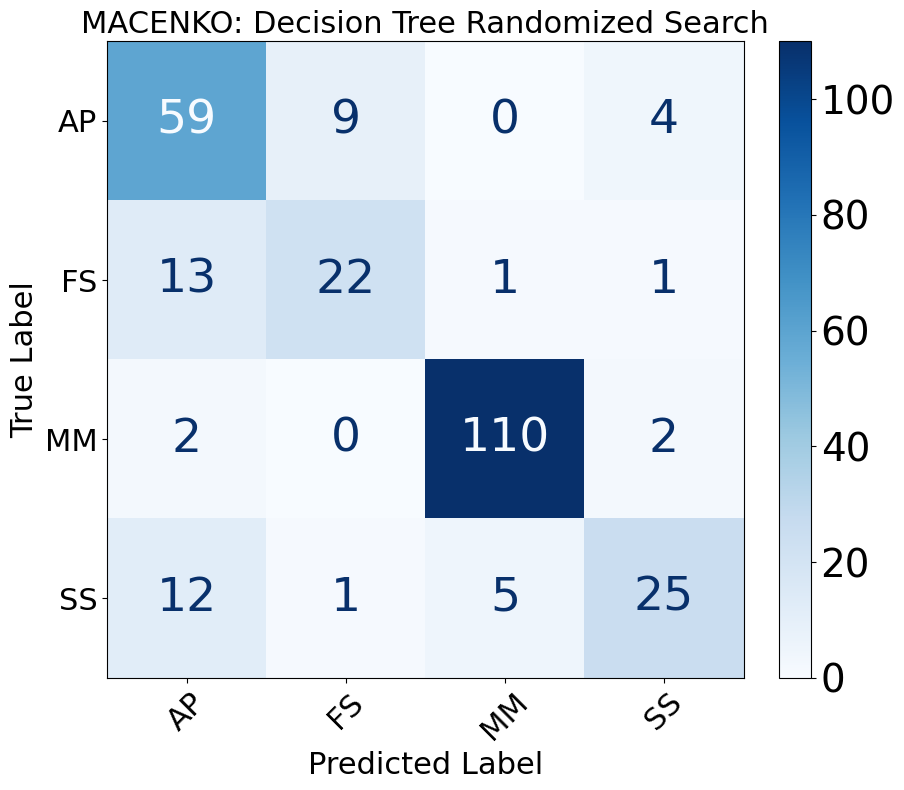

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt_rs = confusion_matrix(val_labels, y_pred_dt_rs, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_rs,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("MACENKO: Decision Tree Randomized Search", fontsize=22)
plt.xlabel("Predicted Label", fontsize=22)
plt.ylabel("True Label", fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



In [ ]:
#Perform Randomized Search for Random Forest
rf_random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                                      param_distributions=rf_params, n_iter=100, cv=5, random_state=42)
rf_random_search.fit(train_features, train_labels)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 10, 20, 30],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42)

In [ ]:
rf_random_search.cv_results_
tuning_result_rf_rs = pd.DataFrame(rf_random_search.cv_results_)


In [ ]:
rf_random_search.best_params_

{'n_estimators': 200,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 30,
 'criterion': 'entropy'}

In [ ]:
y_pred_rf_rs = rf_random_search.predict(val_features)
print("\n Random Forest Randomized Search Performance:")
print("Accuracy:", accuracy_score(val_labels, y_pred_rf_rs))
print("Classification Report:")
print(classification_report(val_labels, y_pred_rf_rs))


 Random Forest Randomized Search Performance:
Accuracy: 0.868421052631579
Classification Report:
              precision    recall  f1-score   support

          AP       0.72      0.99      0.83        72
          FS       0.95      0.54      0.69        37
          MM       0.95      0.99      0.97       114
          SS       1.00      0.63      0.77        43

    accuracy                           0.87       266
   macro avg       0.90      0.79      0.82       266
weighted avg       0.90      0.87      0.86       266



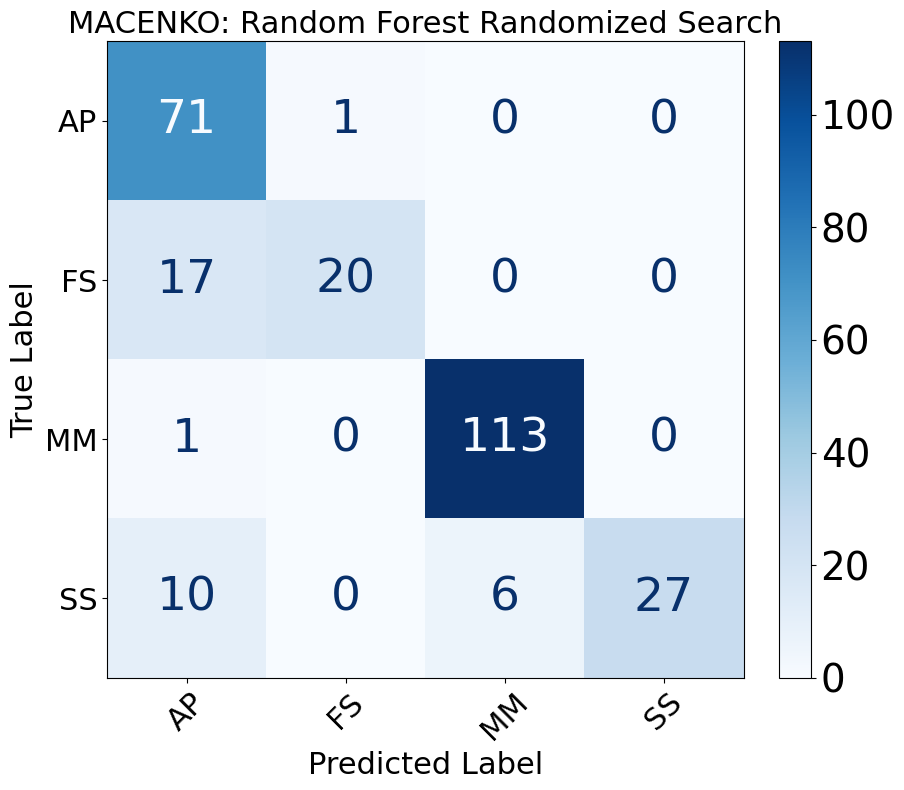

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf_rs = confusion_matrix(val_labels, y_pred_rf_rs, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_rs,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("MACENKO: Random Forest Randomized Search", fontsize=22)
plt.xlabel("Predicted Label", fontsize=22)
plt.ylabel("True Label", fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



In [ ]:
##############################################################
##############################################################

In [ ]:
#Post Pruning for Decision Tree

In [ ]:
#Hyperparameter Tuning
from random import randint
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 50, stop = 500, num = 3)]

# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 3)]
max_depth.append(None)

param_dist = {'n_estimators': n_estimators,
              'max_depth': max_depth}


In [ ]:
#Create a random forest classifier
rf = RandomForestClassifier()
#Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf,
                                 param_distributions= param_dist,
                                 n_iter=5,
                                 cv=5)

In [ ]:
#Fit the random search object to the data
rand_search.fit(train_features, train_labels)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=5,
                   param_distributions={'max_depth': [10, 60, 110, None],
                                        'n_estimators': [50, 275, 500]})

In [ ]:
#Evaluatee model accuracy with best hyperparameters
best_rf = rand_search.best_estimator_
val_pred = best_rf.predict(val_features)
accuracy = accuracy_score(val_labels, val_pred)
print("Validation accuracy with hyperparameter tuning:", accuracy)

Validation accuracy with hyperparameter tuning: 0.8759398496240601


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(val_labels,val_pred))

              precision    recall  f1-score   support

          AP       0.72      0.99      0.84        72
          FS       0.96      0.59      0.73        37
          MM       0.96      0.99      0.97       114
          SS       1.00      0.63      0.77        43

    accuracy                           0.88       266
   macro avg       0.91      0.80      0.83       266
weighted avg       0.90      0.88      0.87       266



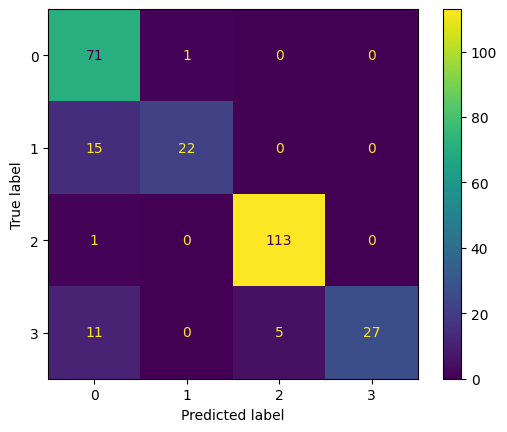

In [ ]:
# Create the confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
cm = confusion_matrix(val_labels, val_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();